In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.sparse as sp
from scipy.sparse.linalg import spsolve
import numpy.linalg as lin

In [50]:
def A_mat(N,h):
    sup = [-1]*(N-1)
    sub = [-1]*(N-1)
    diag = [2]*(N)
    return (1/h) * (sp.diags(sup,offsets=1)+sp.diags(diag,offsets=0)+sp.diags(sub,offsets=-1))

def M_mat(N,h):
    sup = [1]*(N-1)
    sub = [1]*(N-1)
    diag = [4]*(N)
    return (h/6) * (sp.diags(sup,offsets=1)+sp.diags(diag,offsets=0)+sp.diags(sub,offsets=-1))

def u0(x):
    return np.exp(-np.pi**2 * 0)*np.sin(np.pi*x)

def FEM_solver(N,M,T,a,b,theta):
    k = T/M
    h = (b-a) / (N+1)
    A_mat_ = A_mat(N,h)
    M_mat_ = M_mat(N,h)
    x = np.linspace(a,b,num=N+2)
    u = np.zeros(shape=(N+2,M+1))
    u[1:-1,0] = u0(x[1:-1])
    LHS = (M_mat_+k*theta*A_mat_)
    RHS = (M_mat_-k*(1-theta)*A_mat_)
    for t in range(1,M+1):
        u[1:-1,t] = spsolve(LHS,RHS@u[1:-1,t-1])
    return u[1:-1,-1]

def FDM_solver(N,M,T,a,b,theta):
    k = T/M
    h = (b-a) / (N+1)
    A_mat_ = A_mat(N,h)
    M_mat_ = sp.eye(N)
    x = np.linspace(a,b,num=N+2)
    u = np.zeros(shape=(N+2,M+1))
    u[1:-1,0] = u0(x[1:-1])
    LHS = (M_mat_+(k/h)*theta*A_mat_)
    RHS = (M_mat_-(k/h)*(1-theta)*A_mat_)
    for t in range(1,M+1):
        u[1:-1,t] = spsolve(LHS,RHS@u[1:-1,t-1])
    return u[1:-1,-1]



In [202]:
N = 50; a=0; b=1; T=0.1
x = np.linspace(a,b,num=N+2)

u_FEM = FEM_solver(N=N,M=1000,T=T,a=a,b=b,theta=0.5)
u_FDM = FDM_solver(N=N,M=1000,T=T,a=a,b=b,theta=0.5)

C:\Users\trist\AppData\Local\Temp\ipykernel_54760\2859387662.py:27: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  u[1:-1,t] = spsolve(LHS,RHS@u[1:-1,t-1])
C:\Users\trist\AppData\Local\Temp\ipykernel_54760\2859387662.py:41: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  u[1:-1,t] = spsolve(LHS,RHS@u[1:-1,t-1])


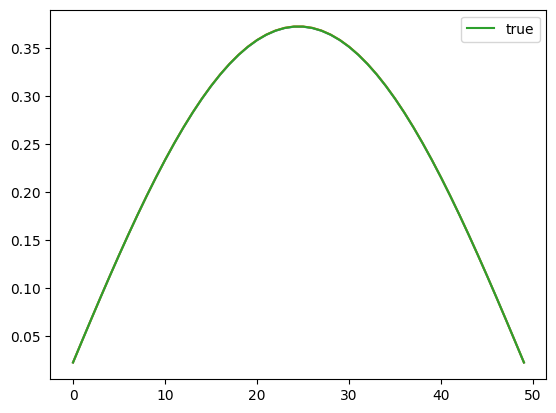

In [203]:
plt.plot(u_FEM)
plt.plot(u_FDM)
plt.plot(np.exp(-np.pi**2*T)*np.sin(np.pi*x[1:-1]),label="true")
plt.legend()
plt.show()

In [204]:
u_true_v = []
u_FEM_v = []
u_FDM_v = []
I = np.array([i**2 for i in range(2,7)])
for i in I:
    x = np.linspace(a,b,num=i+2)
    u_true_v.append(np.exp(-np.pi**2*T)*np.sin(np.pi*x[1:-1]))
    u_FDM_v.append(FDM_solver(N=i,M=100,T=T,a=a,b=b,theta=0.5))
    u_FEM_v.append(FEM_solver(N=i,M=100,T=T,a=a,b=b,theta=0.5))

C:\Users\trist\AppData\Local\Temp\ipykernel_54760\2859387662.py:41: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  u[1:-1,t] = spsolve(LHS,RHS@u[1:-1,t-1])
C:\Users\trist\AppData\Local\Temp\ipykernel_54760\2859387662.py:27: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  u[1:-1,t] = spsolve(LHS,RHS@u[1:-1,t-1])


In [205]:
e_FEM = []
e_FDM = []
for i in range(len(u_true_v)):
    e_FEM.append(sum( (u_true_v[i]-u_FEM_v[i])**2 ))
    e_FDM.append(sum( (u_true_v[i]-u_FDM_v[i])**2 ))

In [206]:
conv_rate_FEM = np.polyfit(np.log(1/I), np.log(e_FEM), deg=1)
conv_rate_FDM = np.polyfit(np.log(1/I), np.log(e_FDM), deg=1)

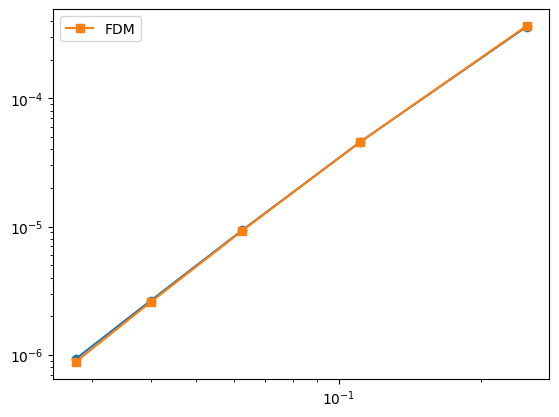

In [207]:
plt.plot(1/I,e_FEM,'-o')
plt.plot(1/I,e_FDM,'-s',label="FDM")
plt.yscale("log")
plt.xscale("log")
plt.legend()
plt.show()

In [208]:
print(conv_rate_FEM[0],conv_rate_FDM[0])

2.7206874983586227 2.7484021456665544
